In this basic analysis I want to look at different ball park statistics for the 2025 season. Things such as batting average per stadium and batting average etc. Then I want to do similar analysis with pitching

In [1]:
import pandas as pd
import matplotlib.pyplot as plt  # data viz
import seaborn as sns            # data viz
import numpy as np
import pybaseball as pyb
from pybaseball import batting_stats, pitching_stats, statcast
import warnings
import pandas as pd
warnings.filterwarnings("ignore") 

#to view entire column
pd.set_option('display.max_colwidth', None)

In [2]:
from pybaseball import statcast

df = statcast(start_dt="2025-03-27", end_dt="2025-10-01")

This is a large query, it may take a moment to complete


100%|████████████████████████████████████████████████████████████████████████████████| 189/189 [02:00<00:00,  1.57it/s]


In [3]:
df.head()

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
343,FF,2025-10-01,96.7,-2.27,5.8,"Smith, Cade",693307,671922,field_out,hit_into_play,...,1,1.04,1.03,1.03,40.4,-0.158216,30.463581,33.767846,36.037304,17.796143
353,FF,2025-10-01,96.3,-2.5,5.7,"Smith, Cade",693307,671922,NaN,swinging_strike,...,1,1.43,0.81,0.81,38.3,-7.785537,33.800045,37.751147,31.781746,12.476826
370,FF,2025-10-01,96.8,-2.51,5.65,"Smith, Cade",693307,671922,NaN,foul,...,1,1.32,0.56,0.56,36.6,7.256222,2.432506,43.471206,32.422763,27.80322
376,FF,2025-10-01,97.5,-2.42,5.72,"Smith, Cade",693307,671922,NaN,ball,...,1,1.25,0.73,0.73,37.3,<NA>,<NA>,<NA>,<NA>,<NA>
401,FF,2025-10-01,96.6,-2.47,5.66,"Smith, Cade",672761,671922,fielders_choice,hit_into_play,...,1,1.42,0.52,-0.52,36.1,-0.840287,7.724722,26.84735,27.45417,17.257405


In [4]:
dfteams = df[['home_team', 'away_team', 'events']].dropna()

In [5]:
dfteams

,home_team,away_team,events
343,CLE,DET,field_out
401,CLE,DET,fielders_choice
469,CLE,DET,strikeout
617,CLE,DET,hit_by_pitch
775,CLE,DET,walk
...,...,...,...
2002,SD,ATL,force_out
2386,SD,ATL,walk
2871,SD,ATL,walk
3528,SD,ATL,field_out


In [6]:
# Only keep rows with actual plate appearances
pa_events = [
    'single', 'double', 'triple', 'home_run', 'walk', 'strikeout',
    'field_out', 'force_out', 'grounded_into_double_play',
    'field_error', 'hit_by_pitch', 'sac_fly', 'sac_bunt', 'other_out'
]

df_pa = df[df['events'].isin(pa_events)]

# Hits
df_pa['is_hit'] = df_pa['events'].isin(['single', 'double', 'triple', 'home_run'])

# At-bats
df_pa['is_ab'] = ~df_pa['events'].isin(['walk', 'hit_by_pitch', 'sac_fly', 'sac_bunt'])

# Home runs
df_pa['is_hr'] = df_pa['events'] == 'home_run'  # <-- FIX

df_pa['game_date'] = pd.to_datetime(df_pa['game_date'])

# Group by park
park_stats = df_pa.groupby('home_team').agg(
    hits=('is_hit', 'sum'),
    at_bats=('is_ab', 'sum'),
    home_runs=('is_hr', 'sum')
).reset_index()

park_stats['batting_avg'] = park_stats['hits'] / park_stats['at_bats']

In [34]:
# Highest batting average parks
park_stats.sort_values('batting_avg', ascending=False).head()

,home_team,hits,at_bats,home_runs,batting_avg
8,COL,1669,5692,217,0.293219
0,ATH,1468,5600,230,0.262143
29,WSH,1421,5492,177,0.258740
4,BOS,1410,5494,158,0.256644
20,PHI,1406,5485,217,0.256335


In [35]:
# Most HR parks
park_stats.sort_values('home_runs', ascending=False).head()

,home_team,hits,at_bats,home_runs,batting_avg
14,LAD,1369,5522,259,0.247917
0,ATH,1468,5600,230,0.262143
3,BAL,1375,5453,228,0.252155
19,NYY,1258,5425,228,0.231889
13,LAA,1327,5428,226,0.244473


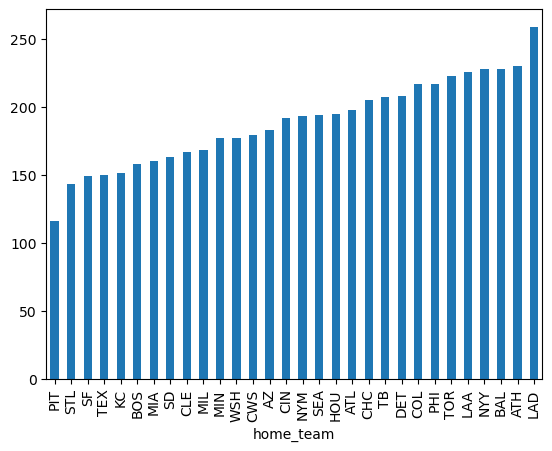

In [9]:
# Graphic of which stadium had the most home runs over the course of a season
park_stats.groupby('home_team')['home_runs'] \
    .mean() \
    .sort_values(ascending=True) \
    .plot.bar();

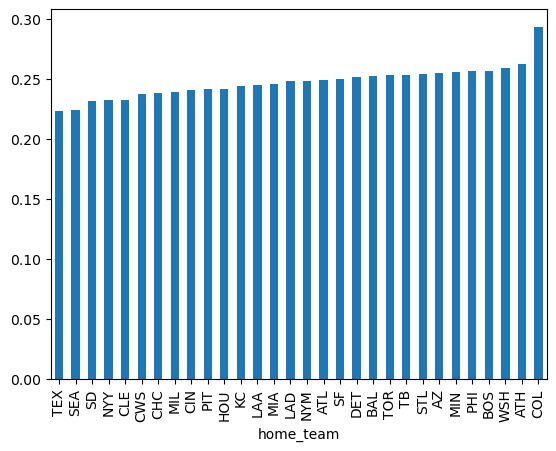

In [10]:
# Graphic of what stadiums had the highest batting average over the course of a season
park_stats.groupby('home_team')['batting_avg'] \
    .mean() \
    .sort_values(ascending=True) \
    .plot.bar();

In [11]:
# Making sure is homerun exists + convert game date to date time
df_pa['is_hr'] = df_pa['events'] == 'home_run'
df_pa['game_date'] = pd.to_datetime(df_pa['game_date'])

# groupby date homerun 
hr_by_team = df_pa.groupby(['home_team', 'game_date'])['is_hr'].sum().reset_index()

# Cumulative home runs
hr_by_team['cum_hr'] = hr_by_team.groupby('home_team')['is_hr'].cumsum()

# Identify top 5 teams 
top_teams = hr_by_team.groupby('home_team')['is_hr'].sum().sort_values(ascending=False).head(5).index

# Filter
hr_top5 = hr_by_team[hr_by_team['home_team'].isin(top_teams)]

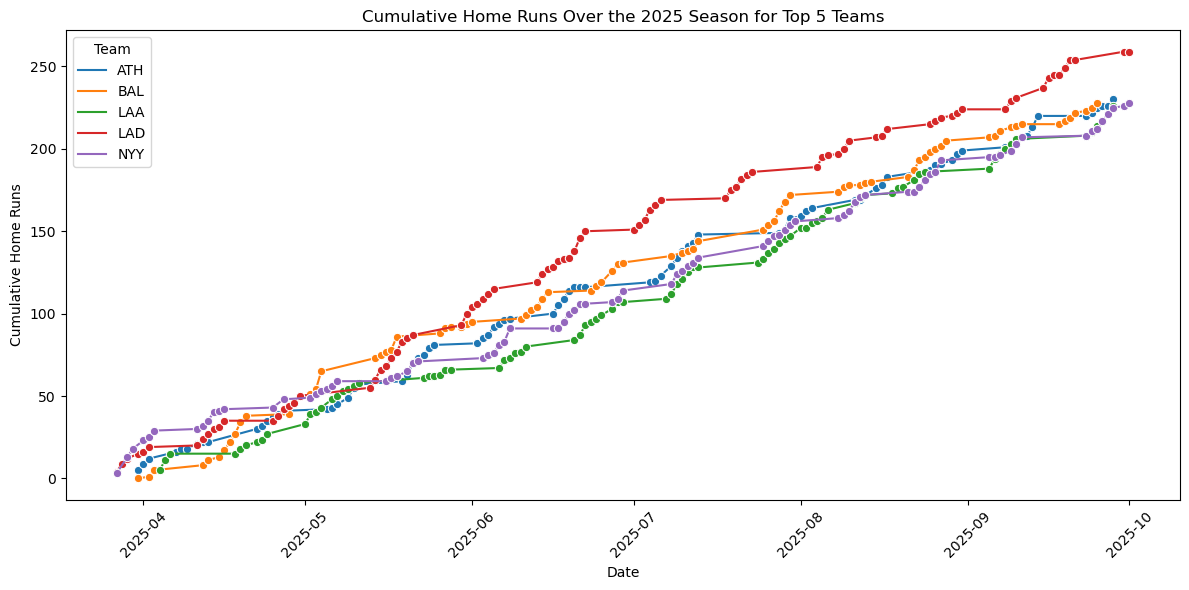

In [12]:
plt.figure(figsize=(12,6))
sns.lineplot(data=hr_top5, x='game_date', y='cum_hr', hue='home_team', marker='o')
plt.title("Cumulative Home Runs Over the 2025 Season for Top 5 Teams")
plt.xlabel("Date")
plt.ylabel("Cumulative Home Runs")
plt.xticks(rotation=45)
plt.legend(title='Team')
plt.tight_layout()
plt.show()

In [17]:
# Creating a runs column 
df_pa['runs_scored'] = df_pa['post_bat_score'] - df_pa['bat_score']
df_pa['runs_scored'] = df_pa['runs_scored'].fillna(0)

In [19]:
runs_by_game = df_pa.groupby(['home_team', 'game_date'])['runs_scored'].sum().reset_index()

In [20]:
runs_by_game = runs_by_game.sort_values(['home_team', 'game_date'])
runs_by_game['cum_runs'] = runs_by_game.groupby('home_team')['runs_scored'].cumsum()

In [24]:
top5_teams = (
    runs_by_game.groupby('home_team')['runs_scored']
    .sum()
    .nlargest(5)
    .index
)
runs_top5 = runs_by_game[runs_by_game['home_team'].isin(top5_teams)]

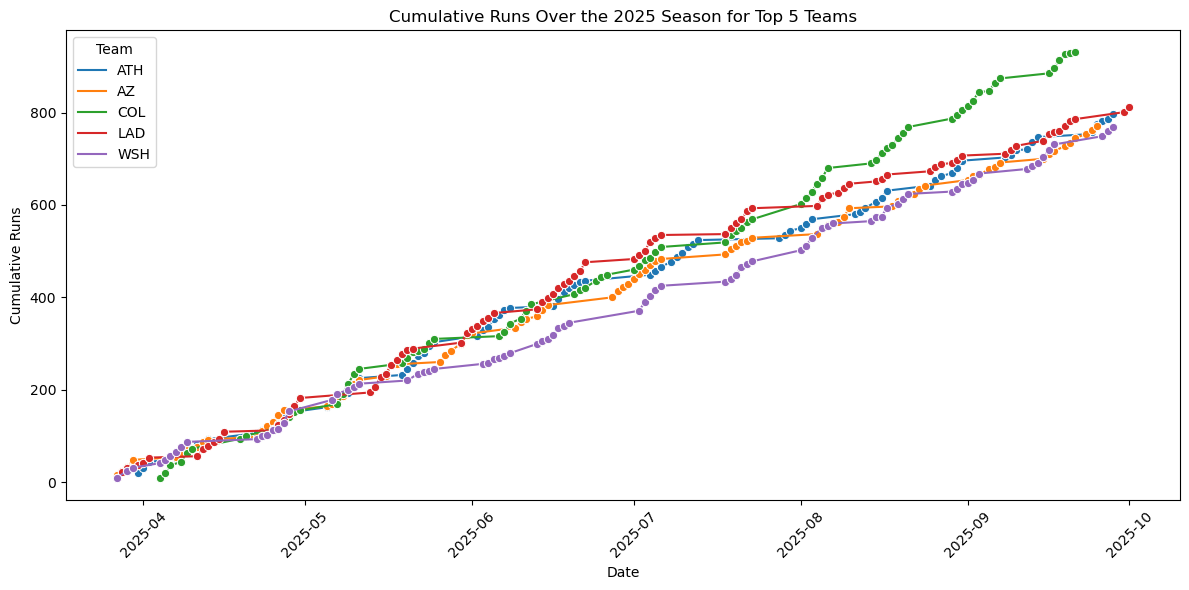

In [25]:
# PLot cumulative runs over the season
plt.figure(figsize=(12,6))
sns.lineplot(
    data=runs_top5,
    x='game_date',
    y='cum_runs',
    hue='home_team',
    marker='o'
)

plt.title("Cumulative Runs Over the 2025 Season for Top 5 Teams")
plt.xlabel("Date")
plt.ylabel("Cumulative Runs")
plt.xticks(rotation=45)
plt.legend(title='Team')
plt.tight_layout()
plt.show()

In [33]:
park_runs = runs_by_game.groupby('home_team')['runs_scored'].sum().reset_index()
park_runs = park_runs.sort_values(by='runs_scored', ascending=False)
park_runs.head()

,home_team,runs_scored
8,COL,932
14,LAD,813
0,ATH,798
2,AZ,771
29,WSH,768
